20.602041703090325
20.684
lambda = 0.4126151313468957

Erros para Nx = 100 e Nt = 1200
L1 = 5947.628680635244
L1 relativo = 0.0002886002009417452
L2 = 904.8668491216227
L2 relativo = 4.3783650446306846e-05
MSE = 8187.840146392936
RMSE = 90.48668491216227
Linf = 388.5152762569487


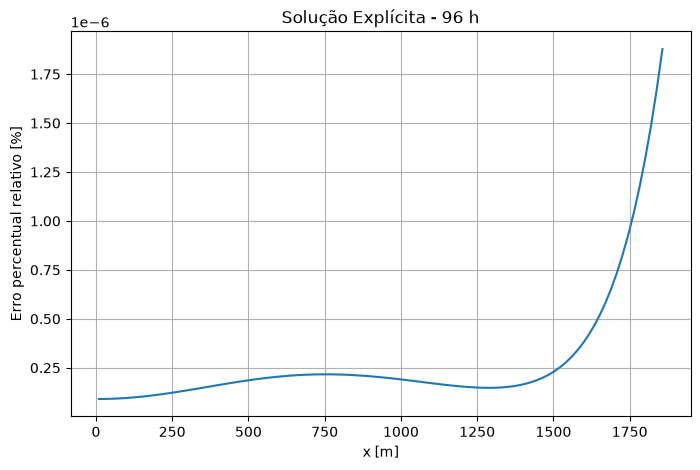

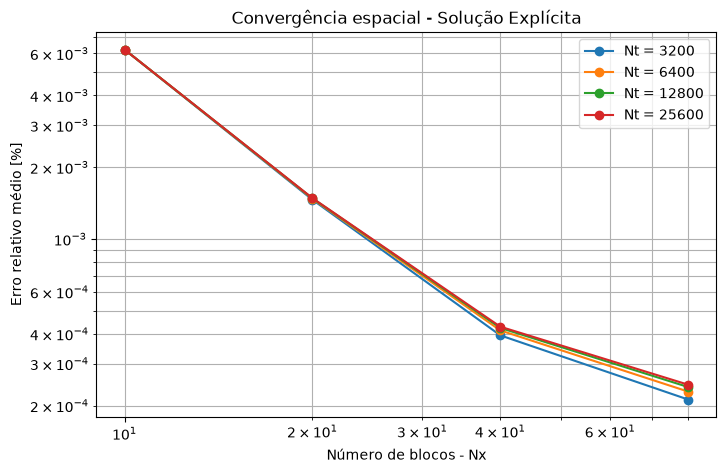

800
1600
3200
6400


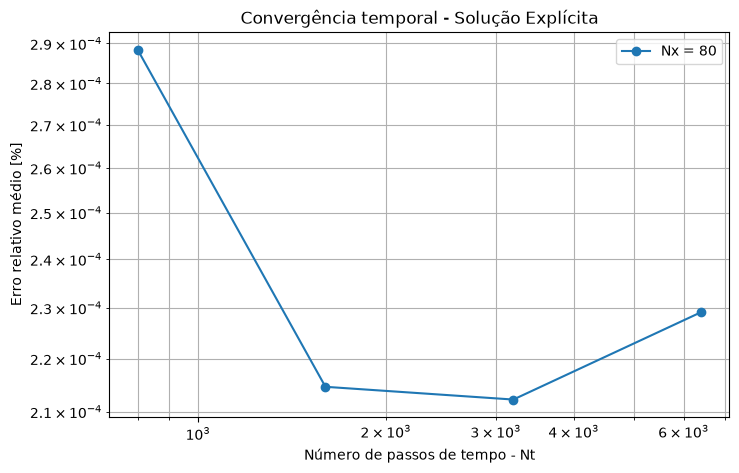

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from analytical.transiente_L1d_FP import linear_trans_1d_FP
from mdf.explicita import explicita_1d_FP

from core.erros import (erro_local, erro_relativo_percentual, erro_L1, erro_L1_relativo, erro_L2, erro_L2_relativo, erro_MSE, erro_RMSE, erro_Linf)

# parâmetros

p0 = 20.684e6
Pe = p0

A_R = 3484800
L = np.sqrt(A_R)

qw = 4.968e-3

k = 339 * 9.869233e-16
phi = 0.22
ct = 3.046e-9
mu = 1.0e-3

h = 4.572
largura = L
A = h * largura

t_h = 96
t_final = t_h * 3600

eta = k / (phi * ct * mu)


# solução analítica

x_an, t_an, X, T, P_an = linear_trans_1d_FP(p0, qw, L, k, A, mu, eta, t_final)


# solução explícita - caso base

nx = 100
nt = 1200

x_exp, t_exp, P_exp, lambd = explicita_1d_FP(p0, Pe, -qw, h, L, k, phi, ct, mu, t_final, nx, nt)

print("lambda =", lambd)


# erros do caso base

# solução analítica nos pontos da malha numérica

P_ref = np.interp(x_exp, x_an, P_an[-1, :])

P_num = P_exp[-1, :]


# erros

local = erro_local(P_ref, P_num)
relativo = erro_relativo_percentual(P_ref, P_num)

L1 = erro_L1(P_ref, P_num)
L1_rel = erro_L1_relativo(P_ref, P_num)

L2 = erro_L2(P_ref, P_num)
L2_rel = erro_L2_relativo(P_ref, P_num)

MSE = erro_MSE(P_ref, P_num)
RMSE = erro_RMSE(P_ref, P_num)

Linf = erro_Linf(P_ref, P_num)


print("\nErros para Nx = 100 e Nt = 1200")

print("L1 =", L1)
print("L1 relativo =", L1_rel)

print("L2 =", L2)
print("L2 relativo =", L2_rel)

print("MSE =", MSE)
print("RMSE =", RMSE)

print("Linf =", Linf)


# erro local

plt.figure(figsize=(8, 5))

plt.plot(x_exp, relativo / 1e3)

plt.xlabel("x [m]")
plt.ylabel("Erro percentual relativo [%]")
plt.title("Solução Explícita - 96 h")

plt.grid()
plt.show()


# refinamento espacial

# varia Nx:
# quanto maior Nx, maior o refinamento espacial

# cada curva corresponde a um Nt diferente

nx_values = [10, 20, 40, 80]

nt_values_espacial = [3200, 6400, 12800, 25600]

plt.figure(figsize=(8, 5))

for nt_i in nt_values_espacial:

    erros_espaciais = []

    for nx_i in nx_values:

        x_i, t_i, P_i, lambd_i = explicita_1d_FP(p0, Pe, -qw, h, L, k, phi, ct, mu, t_final, nx_i, nt_i)

        # solução analítica na malha numérica

        P_ref_i = np.interp(x_i, x_an, P_an[-1, :])

        # erro relativo percentual médio

        erro_i = (erro_L1_relativo(P_ref_i, P_i[-1, :])/ nx_i) * 100

        erros_espaciais.append(erro_i)


    plt.loglog(nx_values, erros_espaciais, "o-", label=f"Nt = {nt_i}")


plt.xlabel("Número de blocos - Nx")
plt.ylabel("Erro relativo médio [%]")
plt.title("Convergência espacial - Solução Explícita")

plt.legend()
plt.grid(True, which="both")
plt.show()


# ==========================================================
# refinamento temporal
#
# varia Nt:
# quanto maior Nt, menor o passo de tempo
#
# cada curva corresponde a um Nx diferente
# ==========================================================

nx_values_temporal = [80]

nt_values = [25, 50, 100, 200, 400, 800, 1600, 3200, 6400]


plt.figure(figsize=(8, 5))


for nx_i in nx_values_temporal:

    nt_estaveis = []
    erros_temporais = []

    dx_i = L / nx_i


    for nt_i in nt_values:

        dt_i = t_final / nt_i

        lambd_i = eta * dt_i / dx_i**2


        # ignora combinações que não satisfazem
        # a estabilidade da formulação explícita

        if lambd_i > 0.5:
            continue
        print(nt_i)

        x_i, t_i, P_i, lambd_i = explicita_1d_FP(p0, Pe, -qw, h, L, k, phi, ct, mu, t_final, nx_i, nt_i)


        # solução analítica na malha numérica

        P_ref_i = np.interp(x_i, x_an, P_an[-1, :])


        # erro relativo percentual médio

        erro_i = (erro_L1_relativo(P_ref_i, P_i[-1, :]) / nx_i) * 100


        nt_estaveis.append(nt_i)

        erros_temporais.append(erro_i)


    plt.loglog(nt_estaveis, erros_temporais, "o-", label=f"Nx = {nx_i}")


plt.xlabel("Número de passos de tempo - Nt")
plt.ylabel("Erro relativo médio [%]")
plt.title("Convergência temporal - Solução Explícita")

plt.legend()
plt.grid(True, which="both")
plt.show()